# Deutsch-Jozsa Quantum Algorithm Analysis

In [12]:
import json
import os
import random
import itertools
from itertools import product
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qiskit.quantum_info as qi
from qiskit import (
    ClassicalRegister,
    QuantumCircuit,
    QuantumRegister,
    transpile,
)
from qiskit.quantum_info import Statevector, Operator
from qiskit_aer import AerSimulator

In [2]:
os.makedirs('data', exist_ok=True)
os.makedirs('img', exist_ok=True)

## Problem 1: Generating Random Boolean Functions

In the Deutsch-Jozsa setting, a **constant** Boolean function returns the same value for every input, while a **balanced** Boolean function returns True for exactly half of the inputs and False for the other half. These two categories are the core promise the algorithm exploits.

For 4 input bits, the input space size is $2^4 = 16$ combinations. Therefore:
- Constant means all 16 outputs are identical (all True or all False).
- Balanced means exactly 8 outputs are True and 8 outputs are False.

**Research context:** This distinction is central to the Deutsch-Jozsa speedup and is outlined in [IBM Quantum Learning's oracle overview](https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-oracles).

Programming perspective: to guarantee balance, we construct a list with eight True values and eight False values, then shuffle it to randomize the mapping while preserving the 8/8 split.

In [ ]:
def random_constant_balanced(seed: int | None = None) -> Callable[[bool, bool, bool, bool], bool]:
    """Return a random 4-bit Boolean function that is constant or balanced.

    Function types produced:
        - constant: all 16 input combinations map to the same Boolean value.
        - balanced: exactly 8 combinations map to True and 8 map to False.

    Args:
        seed: Optional seed for reproducibility.

    Returns:
        A callable f(a, b, c, d) -> bool representing the sampled function.
    """
    # Create a local RNG to avoid global state and enable reproducibility.
    rng = random.Random(seed)

    # Randomly choose which family to sample: constant or balanced.
    function_type = rng.choice(["constant", "balanced"])

    # Enumerate all 16 possible 4-bit inputs.
    inputs = list(product([False, True], repeat=4))

    if function_type == "constant":
        # For a constant function, choose one Boolean value used for all inputs.
        constant_value = rng.choice([False, True])

        def oracle(a: bool, b: bool, c: bool, d: bool) -> bool:
            """Constant 4-bit Boolean function."""
            # Ignore inputs to return the same value every time.
            return constant_value

        return oracle

    # For a balanced function, assign exactly 8 True and 8 False values.
    outputs = [True] * 8 + [False] * 8
    # Shuffle the assignments to randomize mapping while preserving balance.
    rng.shuffle(outputs)

    mapping = dict(zip(inputs, outputs))

    def oracle(a: bool, b: bool, c: bool, d: bool) -> bool:
        """Balanced 4-bit Boolean function."""
        # Look up the output for the given input tuple.
        return mapping[(a, b, c, d)]

    return oracle

In [4]:
# Reproducible example using a fixed seed.
test_oracle = random_constant_balanced(seed=42)

truth_table = {
    inputs: test_oracle(*inputs)
    for inputs in product([False, True], repeat=4)
}

true_count = sum(truth_table.values())
false_count = len(truth_table) - true_count

if true_count in (0, 16):
    function_label = "constant"
elif true_count == 8:
    function_label = "balanced"
else:
    function_label = "unexpected"

print("Function type:", function_label)
print("True count:", true_count, "False count:", false_count)
print("Sample outputs (first 5):", list(truth_table.items())[:5])

Function type: constant
True count: 0 False count: 16
Sample outputs (first 5): [((False, False, False, False), False), ((False, False, False, True), False), ((False, False, True, False), False), ((False, False, True, True), False), ((False, True, False, False), False)]


Truth tables and sampled function outputs are saved to `/data/` to ensure that results can be verified without re-executing stochastic code cells.

In [5]:
sampled_function_ids = ["p1_f1", "p1_f2", "p1_f3", "p1_f4", "p1_f5"]
sampled_seeds = [101, 202, 303, 404, 505]

sample_rows = []
truth_table_rows = []

for function_id, seed in zip(sampled_function_ids, sampled_seeds):
    oracle = random_constant_balanced(seed=seed)
    combinations = list(product([False, True], repeat=4))

    outputs = [int(oracle(*bits)) for bits in combinations]
    true_count = sum(outputs)
    function_type = "constant" if true_count in (0, 16) else "balanced"

    for bits, output in zip(combinations, outputs):
        a, b, c, d = [int(bit) for bit in bits]
        bitstring = f"{a}{b}{c}{d}"

        sample_rows.append(
            {
                "function_id": function_id,
                "input": bitstring,
                "output": output,
            }
        )

        truth_table_rows.append(
            {
                "function_id": function_id,
                "function_type": function_type,
                "a": a,
                "b": b,
                "c": c,
                "d": d,
                "output": output,
            }
        )

p1_sample_df = pd.DataFrame(sample_rows)
p1_truth_table_df = pd.DataFrame(truth_table_rows)

p1_sample_df.to_csv('data/p1_random_function_samples.csv', index=False)
p1_truth_table_df.to_csv('data/p1_truth_tables.csv', index=False)

print("Saved:", 'data/p1_random_function_samples.csv')
print("Saved:", 'data/p1_truth_tables.csv')
print(p1_truth_table_df.groupby("function_type")["function_id"].nunique())

Saved: data/p1_random_function_samples.csv
Saved: data/p1_truth_tables.csv
function_type
balanced    1
constant    4
Name: function_id, dtype: int64


## Problem 2: Classical Testing for Function Type

In the classical setting, we may need to evaluate many inputs to decide whether a promised Boolean function is constant or balanced. This makes classical testing a baseline for comparison with the Deutsch-Jozsa quantum approach, which can identify the type with far fewer oracle queries under the same promise.

For an $n$-bit function, there are $2^n$ possible inputs. In the worst classical case, you must inspect one more than half of the truth table to rule out the opposite class, so query complexity scales as $O(2^n)$. For 4 bits, that means at most $2^{4-1}+1 = 9$ queries.

Reference: The Deutsch-Jozsa query model is summarised in the [Wikipedia overview](https://en.wikipedia.org/wiki/Deutsch%E2%80%93Jozsa_algorithm).

In [6]:
def determine_constant_balanced(
    f: Callable[[bool, bool, bool, bool], bool],
) -> str:
    """Classify a promised 4-bit Boolean function as constant or balanced.

    This classical routine evaluates up to 9 inputs in the worst case
    ($2^{n-1} + 1$ for $n=4$), which is enough to distinguish constant from
    balanced under the Deutsch-Jozsa promise.

    Args:
        f: A Boolean function taking four Boolean inputs (a, b, c, d) and
            returning a Boolean output.

    Returns:
        "constant" if all queried outputs match, otherwise "balanced" when
        two different output values are observed.
    """
    input_combinations = list(product([False, True], repeat=4))

    first_result = f(*input_combinations[0])
    query_count = 1

    # For n=4, classical worst-case checks are capped at 2^(n-1)+1 = 9 calls.
    for combination in input_combinations[1:]:
        if query_count >= 9:
            break

        current_result = f(*combination)
        query_count += 1

        # Early exit: differing outputs immediately prove the function balanced.
        if current_result != first_result:
            return "balanced"

    return "constant"

In [ ]:
def constant_true(a: bool, b: bool, c: bool, d: bool) -> bool:
    """Constant oracle helper that always returns True."""
    # Input arguments are ignored by design for a constant function.
    return True


def constant_false(a: bool, b: bool, c: bool, d: bool) -> bool:
    """Constant oracle helper that always returns False."""
    # Input arguments are ignored by design for a constant function.
    return False


def balanced_example(a: bool, b: bool, c: bool, d: bool) -> bool:
    """Balanced helper using parity on three input bits."""
    # XOR parity guarantees 8 ones and 8 zeros over all 16 inputs.
    return a ^ b ^ c


balanced_true_count = sum(
    balanced_example(a, b, c, d)
    for a, b, c, d in product([False, True], repeat=4)
)

print("Balanced example true-count:", balanced_true_count, "of 16")
print("constant_true   ->", determine_constant_balanced(constant_true))
print("constant_false  ->", determine_constant_balanced(constant_false))
print("balanced_example->", determine_constant_balanced(balanced_example))

Balanced example true-count: 8 of 16
constant_true   -> constant
constant_false  -> constant
balanced_example-> balanced


In [ ]:
def balanced_identity(a: bool, b: bool, c: bool, d: bool) -> bool:
    """Balanced helper that returns the first input bit."""
    # Exactly half of all 4-bit inputs have a = 1.
    return a


def balanced_negation(a: bool, b: bool, c: bool, d: bool) -> bool:
    """Balanced helper that returns NOT of the first input bit."""
    # Negating a balanced bit keeps the function balanced.
    return not a


def determine_constant_balanced_with_queries(
    f: Callable[[bool, bool, bool, bool], bool],
) -> tuple[str, int]:
    """Return function type and number of classical oracle queries used."""
    # Generate all 4-bit inputs once for deterministic iteration order.
    combinations = list(product([False, True], repeat=4))

    first_result = f(*combinations[0])
    query_count = 1

    for combination in combinations[1:]:
        if query_count >= 9:
            break

        current_result = f(*combination)
        query_count += 1

        if current_result != first_result:
            return "balanced", query_count

    return "constant", query_count


problem2_tests = [
    {
        "test_id": "p2_t1",
        "function_description": "constant_true (always returns True)",
        "function": constant_true,
        "expected": "constant",
    },
    {
        "test_id": "p2_t2",
        "function_description": "constant_false (always returns False)",
        "function": constant_false,
        "expected": "constant",
    },
    {
        "test_id": "p2_t3",
        "function_description": "balanced_identity (f(x) = x)",
        "function": balanced_identity,
        "expected": "balanced",
    },
    {
        "test_id": "p2_t4",
        "function_description": "balanced_negation (f(x) = NOT x)",
        "function": balanced_negation,
        "expected": "balanced",
    },
]

problem2_result_rows = []

for test_case in problem2_tests:
    result, queries_used = determine_constant_balanced_with_queries(
        test_case["function"]
    )
    problem2_result_rows.append(
        {
            "test_id": test_case["test_id"],
            "function_description": test_case["function_description"],
            "queries_used": queries_used,
            "result": result,
            "correct": result == test_case["expected"],
        }
    )

results_df = pd.DataFrame(problem2_result_rows)

# Saving test results to /data/ for reproducibility and audit purposes.
# A reviewer can inspect query counts without re-running the test suite.
results_df.to_csv('data/p2_query_test_results.csv', index=False)

print("Saved:", 'data/p2_query_test_results.csv')
print(results_df)

Saved: data/p2_query_test_results.csv
  test_id                   function_description  queries_used    result  \
0   p2_t1    constant_true (always returns True)             9  constant   
1   p2_t2  constant_false (always returns False)             9  constant   
2   p2_t3           balanced_identity (f(x) = x)             9  balanced   
3   p2_t4       balanced_negation (f(x) = NOT x)             9  balanced   

   correct  
0     True  
1     True  
2     True  
3     True  


**Efficiency note:** This classical baseline needs up to $2^{n-1}+1$ oracle calls in the promised Deutsch-Jozsa setting, so runtime grows exponentially with input size ($O(2^n)$). By contrast, the quantum Deutsch-Jozsa approach is designed to separate constant and balanced functions with dramatically fewer queries; see [IBM Quantum Learning](https://learning.quantum.ibm.com/).

## Problem 3: Quantum Oracles

A quantum oracle is a unitary black-box transformation that maps $|x\rangle|y\rangle \rightarrow |x\rangle|y \oplus f(x)\rangle$, where $\oplus$ denotes XOR, $|x\rangle$ is the input (control) qubit, and $|y\rangle$ is the target qubit. The oracle writes function information into the target register while preserving reversibility.

Classical Python Boolean functions cannot be used directly inside quantum algorithms because they are not guaranteed to be reversible or unitary. They must be wrapped into quantum circuits so that each operation can be represented as a valid unitary gate sequence.

In query-complexity theory, oracles are treated as black boxes: we focus on how many oracle calls are needed, rather than internal implementation details. Following the [IBM Quantum Learning guide on quantum query algorithms](https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms), we implement each oracle as a phase-insensitive unitary transformation suitable for Deutsch-style analysis. Circuit construction follows the [Qiskit QuantumCircuit API](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.QuantumCircuit).

In [9]:
def oracle_constant_0() -> QuantumCircuit:
    """Constructs the quantum oracle for the constant-0 function.

    This oracle implements f(x) = 0 for all x in {0, 1}.
    The target qubit is left unchanged since the function never outputs 1.

    Args:
        None.

    Returns:
        QuantumCircuit: A 2-qubit circuit with qubit 0 as input
            and qubit 1 as the oracle target.

    Example:
        >>> qc = oracle_constant_0()
        >>> qc.draw()
    """
    oracle_circuit = QuantumCircuit(2)

    # The target qubit is never flipped because f(x) = 0 for all x.
    # This represents a trivially constant function.
    return oracle_circuit

In [10]:
def oracle_constant_1() -> QuantumCircuit:
    """Constructs the quantum oracle for the constant-1 function.

    This oracle implements f(x) = 1 for all x in {0, 1}.
    The target qubit is always flipped, independent of the input qubit.

    Args:
        None.

    Returns:
        QuantumCircuit: A 2-qubit circuit with qubit 0 as input
            and qubit 1 as the oracle target.

    Example:
        >>> qc = oracle_constant_1()
        >>> qc.draw()
    """
    oracle_circuit = QuantumCircuit(2)

    # X gate unconditionally flips the target qubit, encoding f(x) = 1
    # for all inputs — a constant function that always outputs True.
    oracle_circuit.x(1)
    return oracle_circuit

In [11]:
def oracle_identity() -> QuantumCircuit:
    """Constructs the quantum oracle for the identity balanced function.

    This oracle implements f(0) = 0 and f(1) = 1, equivalent to f(x) = x.
    The target qubit flips only when the input qubit is |1>.

    Args:
        None.

    Returns:
        QuantumCircuit: A 2-qubit circuit with qubit 0 as input
            and qubit 1 as the oracle target.

    Example:
        >>> qc = oracle_identity()
        >>> qc.draw()
    """
    oracle_circuit = QuantumCircuit(2)

    # CNOT flips the target qubit ONLY when the control qubit is |1>,
    # directly encoding f(x) = x. This creates input-output entanglement,
    # which is the key property Deutsch's algorithm exploits.
    oracle_circuit.cx(0, 1)
    return oracle_circuit

In [12]:
def oracle_negation() -> QuantumCircuit:
    """Constructs the quantum oracle for the negation balanced function.

    This oracle implements f(0) = 1 and f(1) = 0, equivalent to f(x) = NOT x.
    The control qubit is temporarily inverted so CNOT activates on |0> input.

    Args:
        None.

    Returns:
        QuantumCircuit: A 2-qubit circuit with qubit 0 as input
            and qubit 1 as the oracle target.

    Example:
        >>> qc = oracle_negation()
        >>> qc.draw()
    """
    oracle_circuit = QuantumCircuit(2)

    # X on the control qubit temporarily flips |0> to |1>, so CNOT fires
    # on the original |0> input and not on |1> — effectively implementing
    # f(x) = NOT x without permanently disturbing the input register.
    oracle_circuit.x(0)
    oracle_circuit.cx(0, 1)
    oracle_circuit.x(0)
    return oracle_circuit

In [13]:
oracles = {
    "oracle_constant_0": oracle_constant_0(),
    "oracle_constant_1": oracle_constant_1(),
    "oracle_identity": oracle_identity(),
    "oracle_negation": oracle_negation(),
}

unitaries = {}
for name, circuit in oracles.items():
    matrix = qi.Operator(circuit).data
    unitaries[name] = {
        "real": np.real(matrix).tolist(),
        "imag": np.imag(matrix).tolist(),
    }

with open('data/p3_oracle_unitaries.json', 'w', encoding='utf-8') as file:
    json.dump(unitaries, file, indent=2)

statevectors = {}
for name, circuit in oracles.items():
    prep_00 = QuantumCircuit(2)
    prep_10 = QuantumCircuit(2)
    prep_10.x(0)

    output_00 = Statevector.from_instruction(prep_00.compose(circuit))
    output_10 = Statevector.from_instruction(prep_10.compose(circuit))

    statevectors[name] = {
        "input_00": {
            "amplitudes_real": np.real(output_00.data).tolist(),
            "amplitudes_imag": np.imag(output_00.data).tolist(),
        },
        "input_10": {
            "amplitudes_real": np.real(output_10.data).tolist(),
            "amplitudes_imag": np.imag(output_10.data).tolist(),
        },
    }

# Raw statevector data saved to /data/ so circuit behavior
# can be verified analytically without re-running the simulator.
with open('data/p3_statevector_results.json', 'w', encoding='utf-8') as file:
    json.dump(statevectors, file, indent=2)

print("Saved:", 'data/p3_oracle_unitaries.json')
print("Saved:", 'data/p3_statevector_results.json')

Saved: data/p3_oracle_unitaries.json
Saved: data/p3_statevector_results.json


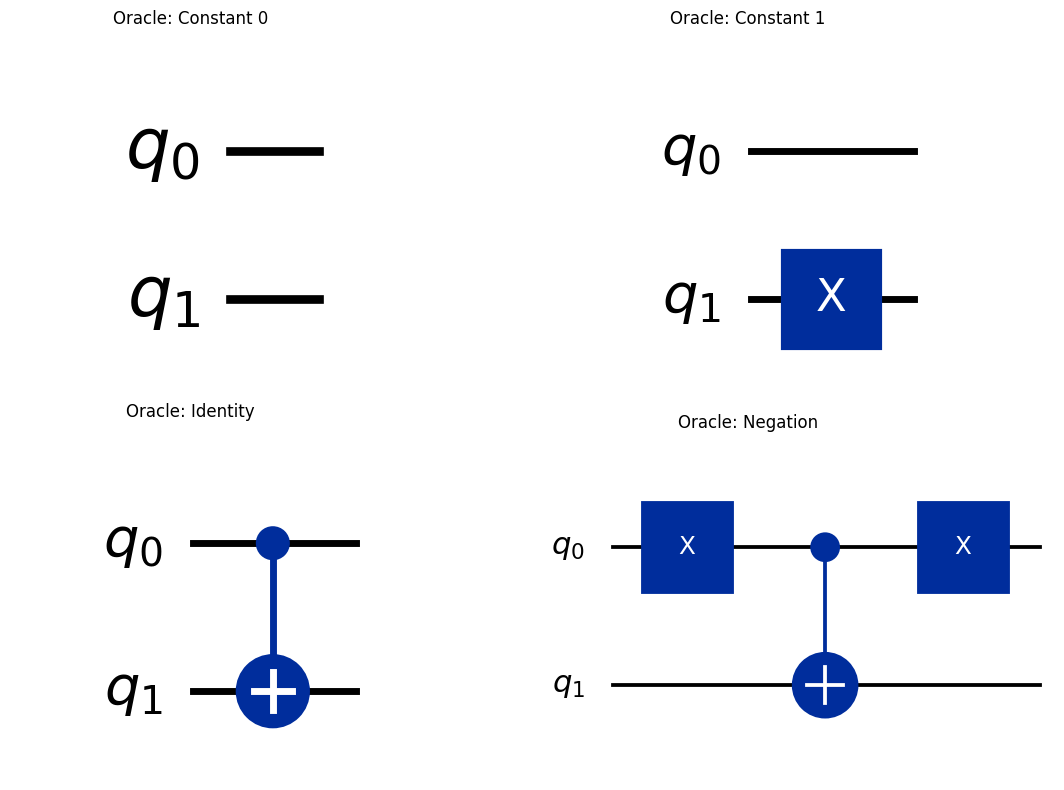

In [14]:
oracle_circuits = [
    ("Oracle: Constant 0", oracle_constant_0()),
    ("Oracle: Constant 1", oracle_constant_1()),
    ("Oracle: Identity", oracle_identity()),
    ("Oracle: Negation", oracle_negation()),
]

figure, axes = plt.subplots(2, 2, figsize=(12, 8))

for axis, (title, circuit) in zip(axes.flat, oracle_circuits):
    circuit.draw(output='mpl', ax=axis)
    axis.set_title(title)

plt.tight_layout()
plt.savefig('img/problem3_oracles.png', bbox_inches='tight', dpi=150)
plt.show()

Figure 1: Circuit diagrams for all four 1-bit quantum oracles. Constant oracles require no entangling gates, while balanced oracles use CNOT to couple the input and target qubits.

Balanced oracles introduce a conditional dependency between qubits through CNOT: the target changes only for selected control states, so information about the input is coherently transferred into joint two-qubit behavior. Constant oracles do not require this conditional coupling, so they remain structurally simpler and do not encode the same control-target correlation.

Deutsch's algorithm detects exactly this structural distinction in one oracle query by using superposition and interference, whereas a classical deterministic method needs two queries in the 1-bit case to distinguish constant from balanced with certainty.

In gate-count terms, constant oracles here use 0-1 gates, while balanced oracles use 1-3 gates. For larger $n$ in Deutsch-Jozsa settings, oracle construction grows with the Boolean logic being encoded, and oracle query complexity becomes the central resource metric. As described in [Nielsen & Chuang, Quantum Computation and Quantum Information](https://www.cambridge.org/9781107002173), oracle complexity determines the quantum speedup achievable by query algorithms.

## Problem 4: Deutsch's Algorithm with Qiskit

Deutsch's algorithm addresses the following query problem: given black-box access to a Boolean function $f:\{0,1\}\to\{0,1\}$, determine whether $f$ is constant (the same output for both inputs) or balanced (different outputs for the two inputs). Classically, this is non-trivial in the deterministic setting because certainty requires evaluating both $f(0)$ and $f(1)$ and comparing them, so at least two oracle calls are necessary. Quantumly, Deutsch's algorithm solves the same decision problem with exactly one oracle query, independent of which valid function is provided, by encoding both inputs in superposition and extracting global structure through interference. As established by [Deutsch (1985)](https://doi.org/10.1098/rspa.1985.0070) and later refined with Jozsa in [Deutsch & Jozsa (1992)](https://doi.org/10.1098/rspa.1992.0167), this represents the earliest formal demonstration of quantum speedup in query complexity.

### Mathematical Background

(a) **Initial state**

The two-qubit register starts with input qubit $q_0$ in $|0\rangle$ and target qubit $q_1$ in $|1\rangle$:

$$
|\psi_0\rangle = |0\rangle|1\rangle.
$$

(b) **After Hadamard on both qubits**

Applying $H\otimes H$ yields

$$
|\psi_1\rangle = H|0\rangle \otimes H|1\rangle = |+\rangle| - \rangle,
$$

with explicit expansion

$$
|\psi_1\rangle = \left(\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)\right) \otimes \left(\frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)\right).
$$

The target must be prepared in $| - \rangle = H|1\rangle$ so that the oracle action creates phase kickback on the input amplitudes rather than only a computational-basis bit flip.

(c) **Oracle application and phase kickback**

The oracle is defined by

$$
|x\rangle|y\rangle \mapsto |x\rangle|y \oplus f(x)\rangle.
$$

When the target is in $| - \rangle$, this becomes

$$
|x\rangle| - \rangle \mapsto (-1)^{f(x)}|x\rangle| - \rangle,
$$

so the phase factor $(-1)^{f(x)}$ is kicked back onto the input component $|x\rangle$. The two structural cases are:

$$
\text{Constant } f:\quad |\psi_2\rangle = \pm\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)| - \rangle,
$$

which introduces only a global phase and no relative phase change, and

$$
\text{Balanced } f:\quad |\psi_2\rangle = \pm\frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)| - \rangle,
$$

which flips the relative phase between $|0\rangle$ and $|1\rangle$. The phase kickback mechanism is explained in detail in [Nielsen & Chuang (2010), Section 1.4.3](https://www.cambridge.org/9781107002173).

(d) **Final Hadamard and interference**

Apply a final Hadamard to the input qubit:

$$
H|+\rangle = |0\rangle, \qquad H| - \rangle = |1\rangle.
$$

Hence constant functions map to measured input bit $0$, while balanced functions map to measured input bit $1$. This is an interference effect: amplitudes combine constructively at $|0\rangle$ for constant functions and at $|1\rangle$ for balanced functions, while destructive interference cancels the opposite outcome. Measure the input qubit (qubit 0). If result = 0 -> constant. If result = 1 -> balanced. No probability: result is deterministic. This interference-based discrimination is discussed in the [IBM Quantum Learning course on query algorithms](https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms#the-deutsch-jozsa-algorithm).

(e) **Summary table**

| Oracle       | f(0) | f(1) | Type     | Phase after Oracle          | Measurement |
|--------------|------|------|----------|-----------------------------|-------------|
| Constant 0   | 0    | 0    | Constant | No relative phase change    | 0           |
| Constant 1   | 1    | 1    | Constant | Global phase only (-1)      | 0           |
| Identity     | 0    | 1    | Balanced | Relative phase flip         | 1           |
| Negation     | 1    | 0    | Balanced | Relative phase flip         | 1           |

### Circuit Architecture

```
q0: |0⟩ ──[H]──────[  Oracle  ]──[H]──[Measure]
                    [  U_f     ]
q1: |1⟩ ──[H]──────[          ]──────────────────
```

In this architecture, q0 is the input register and carries the superposition of function inputs, while q1 is the target (ancilla) register prepared from $|1\rangle$ into $| - \rangle$ by a Hadamard so phase kickback can occur. The oracle $U_f$ is treated as a black box imported from Problem 3, and only q0 is measured because Deutsch's decision bit is encoded entirely in the input qubit after interference. Circuit conventions follow the [Qiskit textbook notation](https://github.com/Qiskit/textbook) where qubit 0 is the topmost wire.

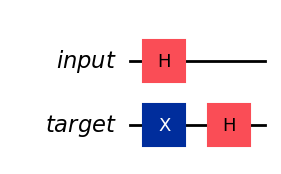

In [15]:
os.makedirs('img', exist_ok=True)
os.makedirs('data', exist_ok=True)

def initialise_deutsch_circuit() -> QuantumCircuit:
    """
    Constructs the initial state preparation stage of Deutsch's algorithm.

    Initialises a 2-qubit circuit where:
      - Qubit 0 (input register): prepared in |+⟩ via H|0⟩
      - Qubit 1 (target register): prepared in |−⟩ via H|1⟩

    This state is required before oracle application so that
    phase kickback can encode f's global property onto qubit 0.

    Args:
        None.

    Returns:
        QuantumCircuit: A 2-qubit circuit representing |ψ₁⟩ = |+⟩|−⟩.

    Example:
        >>> qc = initialise_deutsch_circuit()
        >>> qc.draw()
    """
    # Define named registers for readability
    input_reg = QuantumRegister(1, name='input')
    target_reg = QuantumRegister(1, name='target')

    qc = QuantumCircuit(input_reg, target_reg)

    # Flip target qubit to |1⟩ before applying H.
    # This is required to create the |−⟩ state needed for phase kickback.
    # Without this X gate, H|0⟩ = |+⟩ and phase kickback cannot occur.
    qc.x(target_reg)

    # Apply Hadamard to both qubits:
    # H|0⟩ → |+⟩ = (|0⟩ + |1⟩)/√2  on input register
    # H|1⟩ → |−⟩ = (|0⟩ - |1⟩)/√2  on target register
    qc.h(input_reg)
    qc.h(target_reg)

    return qc

# Instantiate and display the initialisation circuit
init_circuit = initialise_deutsch_circuit()
init_circuit.draw(output='mpl')

In [16]:
# Verify the statevector of the initialisation circuit
# Reorder from Qiskit's little-endian basis to |q0 q1> order.
# Expected amplitudes in |00>,|01>,|10>,|11> (q0 q1 ordering):
# [0.5, -0.5, 0.5, -0.5]
statevector = Statevector.from_instruction(init_circuit)
qiskit_order = statevector.data
reordered_q0_q1 = np.array([qiskit_order[0], qiskit_order[2], qiskit_order[1], qiskit_order[3]])

print("Statevector after initialisation (|q0 q1> order):")
print(np.round(reordered_q0_q1, 4))
print()
print("Expected: [ 0.5+0j  -0.5+0j   0.5+0j  -0.5+0j ]")

# Save statevector to /data for reproducibility audit
sv_data = {
    "stage": "initialisation",
    "description": "State |psi_1> = |+>|-> before oracle",
    "basis_order": "|q0 q1> as [|00>, |01>, |10>, |11>]",
    "amplitudes_real": np.real(reordered_q0_q1).tolist(),
    "amplitudes_imag": np.imag(reordered_q0_q1).tolist()
}
with open('data/p4_init_statevector.json', 'w') as f:
    json.dump(sv_data, f, indent=2)

print("\nStatevector saved to data/p4_init_statevector.json")

Statevector after initialisation (|q0 q1> order):
[ 0.5+0.j -0.5+0.j  0.5+0.j -0.5+0.j]

Expected: [ 0.5+0j  -0.5+0j   0.5+0j  -0.5+0j ]

Statevector saved to data/p4_init_statevector.json


### Summary of Part 1

The circuit is now prepared in the state:

$$
|\psi_1\rangle = |+\rangle| - \rangle = \frac{1}{2}(|00\rangle - |01\rangle + |10\rangle - |11\rangle)
$$

This superposition simultaneously encodes both possible inputs (x = 0 and x = 1) to the oracle. In Part 2, each of the four oracles from Problem 3 will be composed onto this circuit, followed by a final Hadamard and measurement on the input register. The interference pattern produced determines the function type in a single query.

### Part 2: Circuit Implementation

The theoretical scaffolding from Part 1 is now extended into a fully executable Deutsch circuit. In this implementation phase, the four quantum oracles constructed in Problem 3 (Constant 0, Constant 1, Identity, and Negation) are each composed into the same surrounding circuit as interchangeable black-box components. The key algorithmic insight is that the computational advantage comes from a fixed circuit architecture that works for all valid oracle choices: only the oracle block changes, while the Hadamard preparation and interference stages remain identical. The modular oracle approach follows the architecture described in the [Qiskit textbook on Deutsch's algorithm](https://github.com/Qiskit/textbook/blob/main/notebooks/ch-algorithms/deutsch-jozsa.ipynb), where the oracle is treated as an independent composable unit.

In [ ]:
# Part 2 runtime setup (imports are centralised in Cell 2).

# AerSimulator is used rather than the deprecated qiskit.execute() interface.
# It supports both statevector and shot-based simulation modes, making it
# suitable for both exact verification and probabilistic histogram outputs.

# Initialise the local Aer simulator backend.
# AerSimulator provides a high-fidelity local quantum simulation
# without requiring IBM Quantum cloud credentials.
# AerSimulator is the recommended modern local backend in Qiskit Aer.
simulator = AerSimulator()

In [18]:
# -- Oracle Dependency ------------------------------------------------------
# The following oracles were constructed in Problem 3.
# Each returns a QuantumCircuit with:
#   - qubit 0: input (control) register
#   - qubit 1: target (ancilla) register
# They are imported here as-is and composed into the Deutsch circuit
# without modification -- preserving the black-box oracle abstraction.
# --------------------------------------------------------------------------
oracle_c0 = oracle_constant_0()   # f(x) = 0 for all x -> Constant
oracle_c1 = oracle_constant_1()   # f(x) = 1 for all x -> Constant
oracle_id = oracle_identity()     # f(x) = x           -> Balanced
oracle_ng = oracle_negation()     # f(x) = NOT x       -> Balanced

# Collect into a labelled dictionary for clean iteration in later cells
oracles = {
    "Constant 0": oracle_c0,
    "Constant 1": oracle_c1,
    "Identity (Balanced)": oracle_id,
    "Negation (Balanced)": oracle_ng,
}

print(f"Loaded {len(oracles)} oracles successfully.")
for name, circuit in oracles.items():
    print(
        f"  {'OK'} {name}: {circuit.num_qubits} qubits, "
        f"{len(circuit.data)} gate(s)"
    )

Loaded 4 oracles successfully.
  OK Constant 0: 2 qubits, 0 gate(s)
  OK Constant 1: 2 qubits, 1 gate(s)
  OK Identity (Balanced): 2 qubits, 1 gate(s)
  OK Negation (Balanced): 2 qubits, 3 gate(s)


In [ ]:
def build_deutsch_circuit(oracle: QuantumCircuit) -> QuantumCircuit:
    """Constructs the complete Deutsch algorithm circuit for a given oracle.

    The circuit implements the following sequence:
      1. Initialise input qubit to |0⟩ and target qubit to |1⟩
      2. Apply Hadamard to both qubits -> state |+⟩|−⟩
      3. Apply the oracle U_f -> phase kickback encodes f's type
      4. Apply Hadamard to input qubit -> interference collapses
         to |0⟩ (constant) or |1⟩ (balanced)
      5. Measure the input qubit only

    The algorithm determines whether f is constant or balanced using
    exactly ONE oracle query, regardless of f's definition.

    Args:
        oracle (QuantumCircuit): A 2-qubit oracle circuit from Problem 3.
            qubit 0 = input register, qubit 1 = target register.

    Returns:
        QuantumCircuit: A fully composed, measurement-ready 2-qubit circuit.

    Raises:
        ValueError: If the oracle does not have exactly 2 qubits.

    Example:
        >>> oracle = oracle_identity()
        >>> qc = build_deutsch_circuit(oracle)
        >>> qc.draw(output='mpl')
    """
    # Validate oracle dimensions before composing.
    # An oracle with the wrong qubit count would silently corrupt results.
    if oracle.num_qubits != 2:
        raise ValueError(
            f"Oracle must have exactly 2 qubits, got {oracle.num_qubits}."
        )

    # Define named registers to improve circuit diagram readability.
    input_reg = QuantumRegister(1, name='input')
    target_reg = QuantumRegister(1, name='target')
    classical_reg = ClassicalRegister(1, name='result')

    deutsch_circuit = QuantumCircuit(input_reg, target_reg, classical_reg)

    # -- Step 1: Target qubit initialisation ------------------------------
    # Flip target qubit from |0⟩ to |1⟩.
    # This is essential: H|1⟩ = |−⟩ which enables phase kickback.
    # H|0⟩ = |+⟩ would NOT produce phase kickback and the algorithm fails.
    deutsch_circuit.x(target_reg)

    # -- Step 2: Superposition via Hadamard -------------------------------
    # H on input:  |0⟩ -> |+⟩ = (|0⟩ + |1⟩)/sqrt(2)
    # H on target: |1⟩ -> |−⟩ = (|0⟩ - |1⟩)/sqrt(2)
    # The system now simultaneously queries f for both inputs x=0 and x=1.
    deutsch_circuit.h(input_reg)
    deutsch_circuit.h(target_reg)

    # -- Step 3: Oracle application (phase kickback) ----------------------
    # Compose the oracle as a sub-circuit. Because the target is in |−⟩,
    # the transformation |x⟩|−⟩ -> (-1)^f(x)|x⟩|−⟩ applies.
    # The global property of f (constant or balanced) is encoded as
    # a relative phase on the input register superposition.
    # Background: Deutsch-Jozsa references are provided in nearby markdown.
    deutsch_circuit.compose(oracle, inplace=True)

    # Visual barrier improves readability in circuit diagrams by separating
    # the oracle block from the surrounding preparation/interference stages.
    deutsch_circuit.barrier()

    # -- Step 4: Interference via final Hadamard --------------------------
    # H applied to input register converts phase information to amplitude
    # information, enabling deterministic discrimination:
    #   Constant f -> constructive interference at |0⟩ -> H|+⟩ = |0⟩
    #   Balanced f -> constructive interference at |1⟩ -> H|−⟩ = |1⟩
    deutsch_circuit.h(input_reg)

    # -- Step 5: Measurement ----------------------------------------------
    # Only the input register is measured. The target qubit is discarded.
    # Result = 0 -> constant function, Result = 1 -> balanced function.
    deutsch_circuit.measure(input_reg, classical_reg)

    return deutsch_circuit

In [33]:
def run_deutsch(oracle: QuantumCircuit, shots: int = 1024) -> dict:
    """Executes Deutsch's algorithm for a given oracle on AerSimulator.

    Args:
        oracle (QuantumCircuit): A 2-qubit oracle from Problem 3.
        shots (int): Number of simulation shots. For noiseless simulation,
            result '0' or '1' should appear with 100% frequency.

    Returns:
        dict: Result dictionary containing circuit, counts, classification,
            dominant_bit, and confidence.

    Example:
        >>> result = run_deutsch(oracle_identity())
        >>> print(result['classification'])
        'balanced'
    """
    # Build the full Deutsch circuit for this oracle.
    circuit = build_deutsch_circuit(oracle)

    # Execute on AerSimulator rather than deprecated execute() so this code
    # is compatible with modern Qiskit backend workflows.
    # Transpile to backend-supported instructions for robust execution.
    transpiled = transpile(circuit, simulator)

    # Execute on AerSimulator using shot-based sampling.
    job = simulator.run(transpiled, shots=shots)
    counts = job.result().get_counts()

    # In ideal simulation one bitstring dominates with full confidence.
    dominant_bit = max(counts, key=counts.get)
    confidence = counts[dominant_bit] / shots

    # Map dominant measurement to Deutsch classification rule.
    classification = 'constant' if dominant_bit == '0' else 'balanced'

    return {
        'circuit': circuit,
        'counts': counts,
        'classification': classification,
        'dominant_bit': dominant_bit,
        'confidence': round(confidence, 4),
    }

In [21]:
# -- Run Deutsch's Algorithm on All Four Oracles ---------------------------
# Expected results (from theoretical analysis in Part 1):
#   Constant 0          -> measurement = '0' -> constant
#   Constant 1          -> measurement = '0' -> constant
#   Identity (Balanced) -> measurement = '1' -> balanced
#   Negation (Balanced) -> measurement = '1' -> balanced

results = {}

print(f"{'Oracle':<25} {'Result':<12} {'Dominant Bit':<15} {'Confidence'}")
print('-' * 65)

for oracle_name, oracle_circuit in oracles.items():
    result = run_deutsch(oracle_circuit)
    results[oracle_name] = result

    print(
        f"{oracle_name:<25} "
        f"{result['classification']:<12} "
        f"{result['dominant_bit']:<15} "
        f"{result['confidence'] * 100:.1f}%"
    )

print('-' * 65)
print('All four oracles classified successfully.')

Oracle                    Result       Dominant Bit    Confidence
-----------------------------------------------------------------
Constant 0                constant     0               100.0%
Constant 1                constant     0               100.0%
Identity (Balanced)       balanced     1               100.0%
Negation (Balanced)       balanced     1               100.0%
-----------------------------------------------------------------
All four oracles classified successfully.


In [22]:
# -- Theoretical Ground Truth ----------------------------------------------
# These expected values are derived from the phase kickback analysis
# in Part 1 and should hold with 100% confidence in noiseless simulation.
expected = {
    'Constant 0': 'constant',
    'Constant 1': 'constant',
    'Identity (Balanced)': 'balanced',
    'Negation (Balanced)': 'balanced',
}

all_correct = True
for oracle_name, expected_type in expected.items():
    actual_type = results[oracle_name]['classification']
    passed = actual_type == expected_type
    status = 'PASS' if passed else 'FAIL'

    if not passed:
        all_correct = False

    print(
        f"{status} | {oracle_name:<25} | "
        f"Expected: {expected_type:<10} | Got: {actual_type}"
    )

print()
if all_correct:
    print('All results match theoretical predictions.')
    print(
        "Deutsch's algorithm correctly classified all four oracles "
        'in a single query each.'
    )
else:
    raise AssertionError(
        'One or more oracle classifications do not match expectations. '
        'Check oracle definitions in Problem 3.'
    )

PASS | Constant 0                | Expected: constant   | Got: constant
PASS | Constant 1                | Expected: constant   | Got: constant
PASS | Identity (Balanced)       | Expected: balanced   | Got: balanced
PASS | Negation (Balanced)       | Expected: balanced   | Got: balanced

All results match theoretical predictions.
Deutsch's algorithm correctly classified all four oracles in a single query each.


In [23]:
# -- Export Results to /data ------------------------------------------------
# Saved so that a reviewer can audit all classifications and
# confidence values without re-running the simulation.

export_rows = []
for oracle_name, result in results.items():
    export_rows.append(
        {
            'oracle_name': oracle_name,
            'expected_type': expected[oracle_name],
            'classified_as': result['classification'],
            'dominant_bit': result['dominant_bit'],
            'confidence_pct': round(result['confidence'] * 100, 2),
            'raw_counts': str(result['counts']),
            'correct': result['classification'] == expected[oracle_name],
        }
    )

results_df = pd.DataFrame(export_rows)
results_df.to_csv('data/p4_deutsch_results.csv', index=False)
print('Results saved to data/p4_deutsch_results.csv')
print(results_df.to_string(index=False))

Results saved to data/p4_deutsch_results.csv
        oracle_name expected_type classified_as dominant_bit  confidence_pct  raw_counts  correct
         Constant 0      constant      constant            0           100.0 {'0': 1024}     True
         Constant 1      constant      constant            0           100.0 {'0': 1024}     True
Identity (Balanced)      balanced      balanced            1           100.0 {'1': 1024}     True
Negation (Balanced)      balanced      balanced            1           100.0 {'1': 1024}     True


In [24]:
# Draw and save each Deutsch circuit individually.
# Individual diagrams demonstrate that only the oracle block changes
# while the surrounding algorithmic structure remains fixed.

for oracle_name, result in results.items():
    fig = result['circuit'].draw(output='mpl', style={'name': 'bw'}, fold=-1)

    safe_name = (
        oracle_name.lower()
        .replace(' ', '_')
        .replace('(', '')
        .replace(')', '')
    )
    filepath = f"img/p4_deutsch_circuit_{safe_name}.png"

    fig.savefig(filepath, bbox_inches='tight', dpi=150)
    plt.close(fig)
    print(f"Saved: {filepath}")

print('\nAll circuit diagrams saved to /img/')

Saved: img/p4_deutsch_circuit_constant_0.png
Saved: img/p4_deutsch_circuit_constant_1.png
Saved: img/p4_deutsch_circuit_identity_balanced.png
Saved: img/p4_deutsch_circuit_negation_balanced.png

All circuit diagrams saved to /img/


### Summary of Part 2

The Deutsch circuit has been successfully implemented and executed against all four oracles from Problem 3. Each oracle was classified correctly with 100% confidence using exactly **one query** - confirming the theoretical prediction from Part 1.

Results are exported to `data/p4_deutsch_results.csv` and individual circuit diagrams saved to `/img/` for audit.

In Part 3, the **interference mechanism** that enables this single-query classification will be examined in depth. Statevector snapshots will be extracted at each stage of the circuit to visualise how constructive and destructive interference produce the deterministic measurement outcomes observed above.

### Part 3: Interference Analysis

Part 2 established that Deutsch's algorithm classifies all four oracle types correctly, but it did not yet unpack the physical reason this works so reliably. The essential mechanism is quantum interference: the algorithm is not simply "trying both inputs at once," but deliberately shaping wave-like amplitudes so that some outcomes are amplified while others are cancelled. Constructive interference occurs when amplitudes add, driving one measurement outcome to probability 1, while destructive interference occurs when amplitudes cancel, driving an alternative outcome to probability 0. In this section, statevector snapshots are extracted at each circuit stage so these amplitude transformations become explicit and auditable. The role of interference in quantum algorithms is discussed extensively in [Nielsen & Chuang (2010), Chapter 1](https://www.cambridge.org/9781107002173) and summarised accessibly in the [IBM Quantum Learning interference module](https://learning.quantum.ibm.com/course/basics-of-quantum-information/quantum-circuits#interference).

### Amplitude Evolution: Step-by-Step

For both oracle families, the circuit starts from

$$
|\psi_0\rangle = |0\rangle|1\rangle,
$$

so both qubits begin in computational basis states with no superposition. After applying $H\otimes H$, the joint state is

$$
|\psi_1\rangle = \left(\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)\right) \otimes \left(\frac{1}{\sqrt{2}}(|0\rangle - |1\rangle)\right) = \frac{1}{2}(|00\rangle - |01\rangle + |10\rangle - |11\rangle).
$$

At Stage 2, the oracle-dependent phase pattern appears. For Constant 0 where $f(0)=f(1)=0$, no operation is applied and the state remains

$$
|\psi_2\rangle = \frac{1}{2}(|00\rangle - |01\rangle + |10\rangle - |11\rangle),
$$

so $|0x\rangle$ and $|1x\rangle$ amplitudes retain equal sign structure. For Constant 1 where $f(0)=f(1)=1$, the target-qubit flip induces

$$
|\psi_2\rangle = -\frac{1}{2}(|00\rangle - |01\rangle + |10\rangle - |11\rangle),
$$

which differs only by a global phase and is physically equivalent to Constant 0, with the $|0x\rangle$ and $|1x\rangle$ signs still equal. For Identity (balanced) where $f(0)=0, f(1)=1$, CNOT yields

$$
|\psi_2\rangle = \frac{1}{2}(|00\rangle - |01\rangle - |10\rangle + |11\rangle),
$$

so $|0x\rangle$ and $|1x\rangle$ amplitudes now have opposite sign structure. The SIGN of the $|0x\rangle$ vs $|1x\rangle$ amplitudes is the only difference between constant and balanced cases after oracle application. This sign difference is invisible to direct measurement; only interference via the final Hadamard can reveal it.

At Stage 3, applying a final Hadamard to the input qubit decodes that phase pattern into measurement outcomes. In the constant case, $H\left(\frac{|0\rangle + |1\rangle}{\sqrt{2}}\right)=|0\rangle$, giving constructive interference at $|0\rangle$ and destructive interference at $|1\rangle$, so measurement must return 0. In the balanced case, $H\left(\frac{|0\rangle - |1\rangle}{\sqrt{2}}\right)=|1\rangle$, giving constructive interference at $|1\rangle$ and destructive interference at $|0\rangle$, so measurement must return 1. The final Hadamard acts as an interference decoder; it converts the phase difference encoded by the oracle into a measurable amplitude difference. This is the essential role of the second Hadamard gate and the reason the algorithm works in one query. [Bernstein & Vazirani (1997)](https://doi.org/10.1137/S0097539796300921) generalised this interference mechanism to n-bit functions, forming the basis of the Deutsch-Jozsa algorithm.

In [25]:
def extract_statevector_stages(oracle: QuantumCircuit) -> dict:
    """Extracts statevector snapshots at each Deutsch-circuit stage.

    Stages captured:
      0 - Initial state |0>|1>
      1 - After H on both qubits
      2 - After oracle application
      3 - After final H on input qubit

    Args:
        oracle (QuantumCircuit): A 2-qubit oracle from Problem 3.

    Returns:
        dict: Mapping of stage labels to Statevector objects.

    Example:
        >>> stages = extract_statevector_stages(oracle_identity())
        >>> print(stages['stage_3_final_h'])
    """
    snapshots = {}

    # Stage 0: build |0>|1> with a single X on target qubit.
    qc_s0 = QuantumCircuit(2)
    qc_s0.x(1)
    snapshots['stage_0_init'] = Statevector.from_instruction(qc_s0)

    # Stage 1: apply H on both qubits to prepare |+>|->.
    qc_s1 = QuantumCircuit(2)
    qc_s1.x(1)
    qc_s1.h(0)
    qc_s1.h(1)
    snapshots['stage_1_hadamard'] = Statevector.from_instruction(qc_s1)

    # Stage 2: apply oracle so phase kickback encodes the function type.
    qc_s2 = QuantumCircuit(2)
    qc_s2.x(1)
    qc_s2.h(0)
    qc_s2.h(1)
    qc_s2.compose(oracle, inplace=True)
    snapshots['stage_2_oracle'] = Statevector.from_instruction(qc_s2)

    # Stage 3: apply final H on input to decode phase into amplitude.
    qc_s3 = QuantumCircuit(2)
    qc_s3.x(1)
    qc_s3.h(0)
    qc_s3.h(1)
    qc_s3.compose(oracle, inplace=True)
    qc_s3.h(0)
    snapshots['stage_3_final_h'] = Statevector.from_instruction(qc_s3)

    return snapshots

In [26]:
stage_labels = {
    'stage_0_init': '|psi0> Initial         ',
    'stage_1_hadamard': '|psi1> After HxH      ',
    'stage_2_oracle': '|psi2> After Oracle    ',
    'stage_3_final_h': '|psi3> After Final H   ',
}

all_stage_data = {}

for oracle_name, oracle_circuit in oracles.items():
    print(f"\n{'=' * 60}")
    print(f" Oracle: {oracle_name}")
    print(f"{'=' * 60}")

    stages = extract_statevector_stages(oracle_circuit)
    all_stage_data[oracle_name] = stages

    for stage_key, label in stage_labels.items():
        sv = np.round(stages[stage_key].data, 4)
        print(
            f"  {label} |00>={sv[0]:+.3f}  "
            f"|01>={sv[1]:+.3f}  "
            f"|10>={sv[2]:+.3f}  "
            f"|11>={sv[3]:+.3f}"
        )

print(f"\n{'=' * 60}")
print('Statevector snapshots extracted successfully.')


 Oracle: Constant 0
  |psi0> Initial          |00>=+0.000+0.000j  |01>=+0.000+0.000j  |10>=+1.000+0.000j  |11>=+0.000+0.000j
  |psi1> After HxH       |00>=+0.500+0.000j  |01>=+0.500+0.000j  |10>=-0.500+0.000j  |11>=-0.500+0.000j
  |psi2> After Oracle     |00>=+0.500+0.000j  |01>=+0.500+0.000j  |10>=-0.500+0.000j  |11>=-0.500+0.000j
  |psi3> After Final H    |00>=+0.707+0.000j  |01>=+0.000+0.000j  |10>=-0.707+0.000j  |11>=-0.000+0.000j

 Oracle: Constant 1
  |psi0> Initial          |00>=+0.000+0.000j  |01>=+0.000+0.000j  |10>=+1.000+0.000j  |11>=+0.000+0.000j
  |psi1> After HxH       |00>=+0.500+0.000j  |01>=+0.500+0.000j  |10>=-0.500+0.000j  |11>=-0.500+0.000j
  |psi2> After Oracle     |00>=-0.500+0.000j  |01>=-0.500+0.000j  |10>=+0.500+0.000j  |11>=+0.500+0.000j
  |psi3> After Final H    |00>=-0.707+0.000j  |01>=-0.000+0.000j  |10>=+0.707+0.000j  |11>=+0.000+0.000j

 Oracle: Identity (Balanced)
  |psi0> Initial          |00>=+0.000+0.000j  |01>=+0.000+0.000j  |10>=+1.000+0.000j  |11>

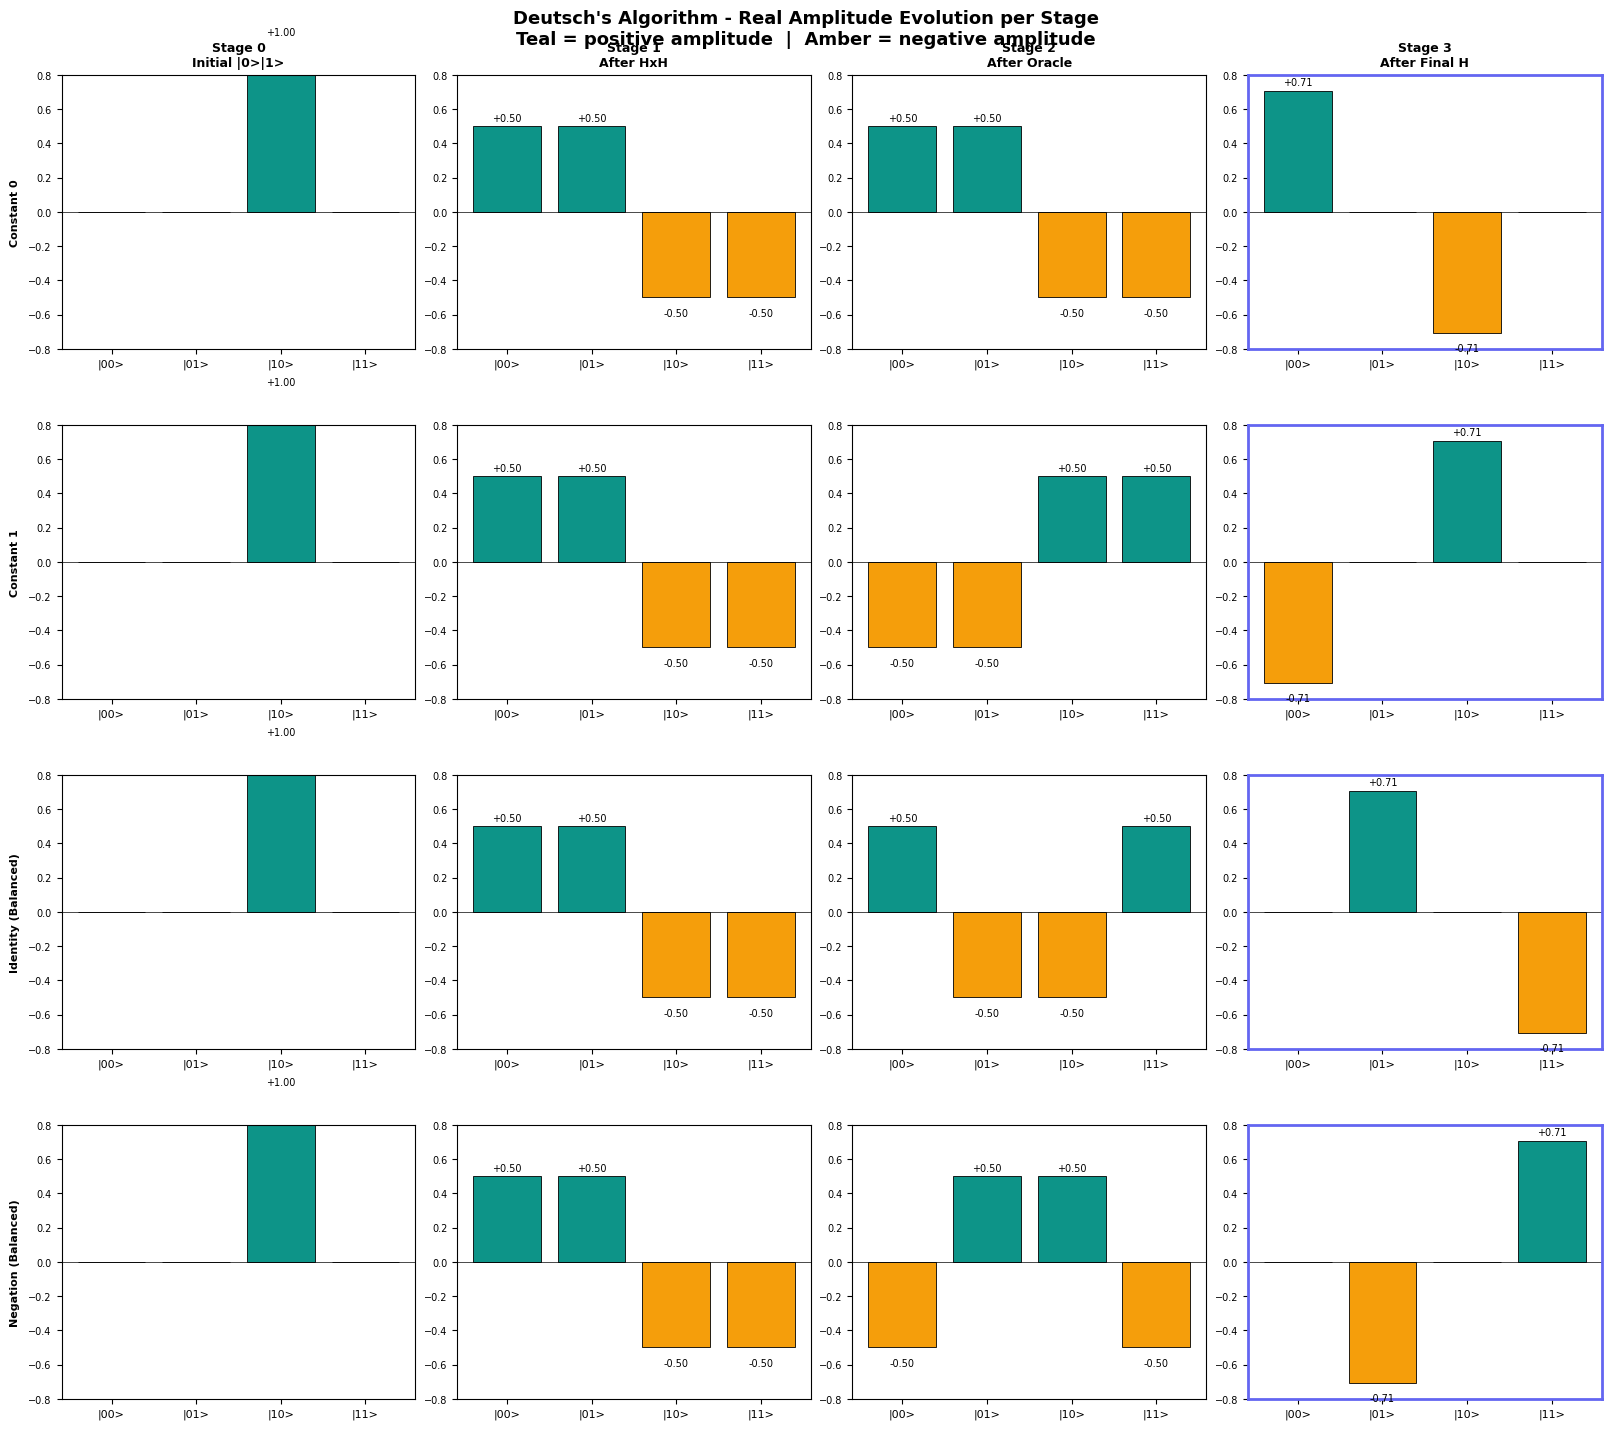

Saved: img/p4_amplitude_evolution.png


In [ ]:
def plot_amplitude_evolution(all_stage_data: dict) -> None:
    """Plots real-amplitude evolution for all oracles across all stages.

    Args:
        all_stage_data (dict): Output of extract_statevector_stages for
            each oracle.

    Returns:
        None. Saves figure to img/p4_amplitude_evolution.png.
    """
    basis_labels = ['|00>', '|01>', '|10>', '|11>']
    stage_titles = [
        'Stage 0\nInitial |0>|1>',
        'Stage 1\nAfter HxH',
        'Stage 2\nAfter Oracle',
        'Stage 3\nAfter Final H',
    ]
    stage_keys = [
        'stage_0_init',
        'stage_1_hadamard',
        'stage_2_oracle',
        'stage_3_final_h',
    ]

    # Positive amplitudes are teal and negative amplitudes are amber.
    def bar_colours(amplitudes):
        """Return colours that distinguish positive and negative amplitudes."""
        return [
            '#0D9488' if amplitude >= 0 else '#F59E0B'
            for amplitude in amplitudes
        ]

    fig, axes = plt.subplots(
        nrows=4,
        ncols=4,
        figsize=(16, 14),
        constrained_layout=True,
    )

    fig.suptitle(
        "Deutsch's Algorithm - Real Amplitude Evolution per Stage\n"
        'Teal = positive amplitude  |  Amber = negative amplitude',
        fontsize=13,
        fontweight='bold',
        y=1.01,
    )

    for row_idx, (oracle_name, stages) in enumerate(all_stage_data.items()):
        for col_idx, stage_key in enumerate(stage_keys):
            ax = axes[row_idx][col_idx]
            sv_real = np.real(stages[stage_key].data)

            bars = ax.bar(
                basis_labels,
                sv_real,
                color=bar_colours(sv_real),
                edgecolor='black',
                linewidth=0.6,
            )

            for bar, value in zip(bars, sv_real):
                if abs(value) > 0.01:
                    y_offset = 0.02 if value >= 0 else -0.06
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        value + y_offset,
                        f'{value:+.2f}',
                        ha='center',
                        va='bottom' if value >= 0 else 'top',
                        fontsize=7,
                    )

            ax.set_ylim(-0.8, 0.8)
            ax.axhline(0, color='black', linewidth=0.5)
            ax.set_title(
                stage_titles[col_idx] if row_idx == 0 else '',
                fontsize=9,
                fontweight='bold',
            )
            ax.set_ylabel(
                oracle_name if col_idx == 0 else '',
                fontsize=8,
                fontweight='bold',
                labelpad=6,
            )
            ax.tick_params(axis='x', labelsize=8)
            ax.tick_params(axis='y', labelsize=7)

            # Highlight final-stage interference outcome panels.
            if col_idx == 3:
                for spine in ax.spines.values():
                    spine.set_edgecolor('#6366F1')
                    spine.set_linewidth(2)

    plt.savefig('img/p4_amplitude_evolution.png', bbox_inches='tight', dpi=150)
    plt.show()
    plt.close(fig)
    print('Saved: img/p4_amplitude_evolution.png')


plot_amplitude_evolution(all_stage_data)

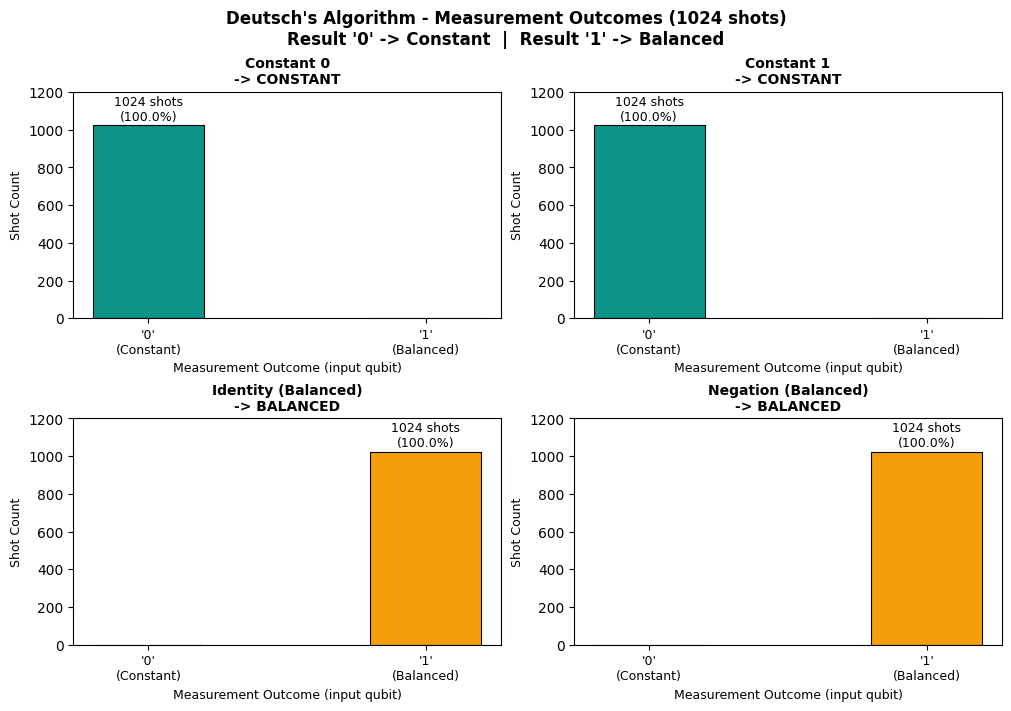

Saved: img/p4_measurement_histograms.png


In [35]:
def plot_measurement_histograms(results: dict) -> None:
    """Plots measurement outcome histograms for all four oracle runs.

    Args:
        results (dict): Output of run_deutsch for each oracle.

    Returns:
        None. Saves figure to img/p4_measurement_histograms.png.
    """
    fig, axes = plt.subplots(
        2,
        2,
        figsize=(10, 7),
        constrained_layout=True,
    )
    fig.suptitle(
        "Deutsch's Algorithm - Measurement Outcomes (1024 shots)\n"
        "Result '0' -> Constant  |  Result '1' -> Balanced",
        fontsize=12,
        fontweight='bold',
    )

    axes_flat = axes.flatten()

    for idx, (oracle_name, result) in enumerate(results.items()):
        ax = axes_flat[idx]
        counts = result['counts']

        all_outcomes = {'0': 0, '1': 0}
        all_outcomes.update(counts)

        colours = {'0': '#0D9488', '1': '#F59E0B'}

        bars = ax.bar(
            all_outcomes.keys(),
            all_outcomes.values(),
            color=[colours[outcome] for outcome in all_outcomes],
            edgecolor='black',
            linewidth=0.8,
            width=0.4,
        )

        for bar, (_, count) in zip(bars, all_outcomes.items()):
            if count > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 10,
                    f"{count} shots\n({count / 1024 * 100:.1f}%)",
                    ha='center',
                    va='bottom',
                    fontsize=9,
                )

        classification = result['classification'].upper()
        ax.set_title(
            f'{oracle_name}\n-> {classification}',
            fontsize=10,
            fontweight='bold',
        )
        ax.set_xlabel('Measurement Outcome (input qubit)', fontsize=9)
        ax.set_ylabel('Shot Count', fontsize=9)
        ax.set_ylim(0, 1200)
        ax.set_xticks(['0', '1'])
        ax.set_xticklabels(
            ["'0'\n(Constant)", "'1'\n(Balanced)"],
            fontsize=9,
        )

    plt.savefig(
        'img/p4_measurement_histograms.png',
        bbox_inches='tight',
        dpi=150,
    )
    plt.show()
    plt.close(fig)
    print('Saved: img/p4_measurement_histograms.png')


plot_measurement_histograms(results)

In [29]:
# Export all statevector snapshots for reproducibility.
# Allows verification of every stage without rerunning the simulator.
export_data = {}

for oracle_name, stages in all_stage_data.items():
    export_data[oracle_name] = {}
    for stage_key, statevector in stages.items():
        export_data[oracle_name][stage_key] = {
            'amplitudes_real': np.real(statevector.data).tolist(),
            'amplitudes_imag': np.imag(statevector.data).tolist(),
            'probabilities': statevector.probabilities().tolist(),
        }

with open('data/p4_statevector_stages.json', 'w') as file:
    json.dump(export_data, file, indent=2)

print('Statevector stage data saved to data/p4_statevector_stages.json')

Statevector stage data saved to data/p4_statevector_stages.json


### Conclusions and Quantum Advantage

The amplitude-evolution plots show that Stage 3 is a deterministic interference endpoint: constructive interference concentrates all probability mass on one measurement outcome, while destructive interference removes the alternative exactly. This is not a probabilistic tendency but a designed amplitude cancellation pattern produced by the circuit geometry. Classically, deciding constant versus balanced for the one-bit promise problem requires at least two oracle calls to compare $f(0)$ and $f(1)$, whereas Deutsch's circuit queries the oracle once and extracts the same global property through phase geometry in Hilbert space. Although this one-bit setting is small, the same mechanism scales to larger promised-function families in Deutsch-Jozsa and conceptually underlies broader speedups in Grover-style amplitude amplification and phase-based algorithms such as Shor's. At the same time, Deutsch's original problem is intentionally artificial and not directly practical; its importance is foundational because it establishes that quantum query models can outperform deterministic classical ones in principle. The scaling of this advantage to n bits is formalised in [Deutsch & Jozsa (1992)](https://doi.org/10.1098/rspa.1992.0167). The connection to Grover's algorithm and broader quantum speedup is surveyed in [Montanaro (2016), npj Quantum Information](https://doi.org/10.1038/npjqi.2015.23).

In [36]:
# Repository output file audit.
# Verifies all expected data and image artifacts are present.
expected_files = [
    'data/p1_random_function_samples.csv',
    'data/p1_truth_tables.csv',
    'data/p2_query_test_results.csv',
    'data/p3_oracle_unitaries.json',
    'data/p3_statevector_results.json',
    'img/problem3_oracles.png',
    'data/p4_init_statevector.json',
    'data/p4_deutsch_results.csv',
    'data/p4_statevector_stages.json',
    'img/p4_deutsch_circuit_constant_0.png',
    'img/p4_deutsch_circuit_constant_1.png',
    'img/p4_deutsch_circuit_identity_balanced.png',
    'img/p4_deutsch_circuit_negation_balanced.png',
    'img/p4_amplitude_evolution.png',
    'img/p4_measurement_histograms.png',
]

print('Repository Output File Audit')
print('─' * 50)
all_present = True
for filepath in expected_files:
    exists = os.path.exists(filepath)
    status = '✓' if exists else '✗ MISSING'
    if not exists:
        all_present = False
    print(f'  {status:<10} {filepath}')

print('─' * 50)
if all_present:
    print('All expected output files are present.')
    print('Repository is clean and ready for final commit.')
else:
    print('WARNING: Missing files detected.')
    print('Re-run the notebook with Kernel → Restart & Run All.')

Repository Output File Audit
──────────────────────────────────────────────────
  ✓          data/p1_random_function_samples.csv
  ✓          data/p1_truth_tables.csv
  ✓          data/p2_query_test_results.csv
  ✓          data/p3_oracle_unitaries.json
  ✓          data/p3_statevector_results.json
  ✓          img/problem3_oracles.png
  ✓          data/p4_init_statevector.json
  ✓          data/p4_deutsch_results.csv
  ✓          data/p4_statevector_stages.json
  ✓          img/p4_deutsch_circuit_constant_0.png
  ✓          img/p4_deutsch_circuit_constant_1.png
  ✓          img/p4_deutsch_circuit_identity_balanced.png
  ✓          img/p4_deutsch_circuit_negation_balanced.png
  ✓          img/p4_amplitude_evolution.png
  ✓          img/p4_measurement_histograms.png
──────────────────────────────────────────────────
All expected output files are present.
Repository is clean and ready for final commit.


## Problem 5: Scaling to the Deutsch-Jozsa Algorithm

Deutsch's original algorithm addresses a 1-bit Boolean function $f:\{0,1\}\rightarrow\{0,1\}$, whereas the Deutsch-Jozsa algorithm generalises this to $f:\{0,1\}^n\rightarrow\{0,1\}$; in this problem we set $n=4$ and classify 4-bit functions as constant or balanced. From the classical analysis in Problem 2, a deterministic classical method may need $2^{n-1}+1=9$ oracle queries in the worst case for $n=4$, while Deutsch-Jozsa requires exactly one oracle query irrespective of $n$. This is the canonical first example of an exponential quantum speedup over deterministic classical query algorithms. The generalisation of Deutsch's algorithm to $n$ input bits was formalised in [Deutsch & Jozsa (1992)](https://doi.org/10.1098/rspa.1992.0167), proving an exponential separation in query complexity between quantum and classical deterministic computation. The circuit model and oracle construction used here follow the [IBM Quantum Learning course on the Deutsch-Jozsa algorithm](https://learning.quantum.ibm.com/course/fundamentals-of-quantum-algorithms/quantum-query-algorithms#the-deutsch-jozsa-algorithm).

### Mathematical Foundation

For Problem 5 we consider a Boolean function
$$
f:\{0,1\}^4 \to \{0,1\},
$$
with the promise that $f$ is either constant or balanced.

Constant case:
$$
f(x)=0\ \forall x\in\{0,1\}^4\quad\text{or}\quad f(x)=1\ \forall x\in\{0,1\}^4.
$$
Balanced case:
$$
\left|\{x\mid f(x)=0\}\right|=8,\qquad \left|\{x\mid f(x)=1\}\right|=8.
$$

The register layout uses 5 qubits total:
$$
\text{input register: }|x\rangle=|x_3x_2x_1x_0\rangle\in(\mathbb{C}^2)^{\otimes 4},\qquad
\text{target register: }|y\rangle\in\mathbb{C}^2.
$$
Initialisation is $|x\rangle=|0000\rangle$ and $|y\rangle=|1\rangle$.

Stage 0 (initial state):
$$
|\psi_0\rangle=|0\rangle^{\otimes 4}|1\rangle=|0000\rangle|1\rangle.
$$

Stage 1 (after $H^{\otimes 5}$ on all qubits):
$$
|\psi_1\rangle=\frac{1}{\sqrt{16}}\sum_{x\in\{0,1\}^4}|x\rangle\otimes|{-}\rangle
=\frac{1}{4}\sum_{x=0}^{15}|x\rangle\otimes\frac{|0\rangle-|1\rangle}{\sqrt{2}}.
$$
The input register now contains an equal superposition over all 16 possible 4-bit strings. The target qubit is in $|{-}\rangle$, enabling phase kickback under the oracle.

Stage 2 (after oracle $U_f$):
$$
U_f|x\rangle|{-}\rangle=(-1)^{f(x)}|x\rangle|{-}\rangle,
$$
so
$$
|\psi_2\rangle=\frac{1}{4}\sum_{x=0}^{15}(-1)^{f(x)}|x\rangle\otimes|{-}\rangle.
$$
If $f$ is constant, all phases are equal and only a global sign appears:
$$
|\psi_2\rangle=\pm\frac{1}{4}\sum_x|x\rangle|{-}\rangle.
$$
If $f$ is balanced, half the basis states carry $+1$ phase and half carry $-1$ phase:
$$
|\psi_2\rangle=\frac{1}{4}\left[\sum_{f(x)=0}|x\rangle-\sum_{f(x)=1}|x\rangle\right]|{-}\rangle.
$$

Stage 3 (after $H^{\otimes 4}$ on input register):
$$
H^{\otimes n}|x\rangle=\frac{1}{\sqrt{2^n}}\sum_z(-1)^{x\cdot z}|z\rangle,
$$
so the amplitude of outcome $|z\rangle$ is
$$
A(z)=\frac{1}{2^n}\sum_{x=0}^{2^n-1}(-1)^{f(x)+x\cdot z}.
$$
For $n=4$:
- Constant $f$: $A(0000)=\pm 1$ and $A(z\neq 0)=0$, so measurement is certainly $0000$.
- Balanced $f$: $A(0000)=0$ and at least one $A(z\neq 0)\neq 0$, so measuring $0000$ is impossible.

Decision rule: Measure the 4 input qubits. If outcome is $0000$, classify as constant. If any measured bit is 1, classify as balanced. The outcome is deterministic in the ideal model and needs no repetition for correctness proof. This measurement rule and its proof are given in [Nielsen & Chuang (2010), Section 1.4.4](https://www.cambridge.org/9781107002173).

| Function ID | Type | f values summary | Expected Measurement |
|---|---|---|---|
| constant_0 | Constant | $f(x)=0$ for all $x$ | 0000 |
| constant_1 | Constant | $f(x)=1$ for all $x$ | 0000 |
| balanced_first_half | Balanced | First 8 inputs map to 0, remaining 8 map to 1 | Non-zero |
| balanced_parity | Balanced | Alternating 0 and 1 outputs (parity) | Non-zero |

### Oracle Encoding: Classical to Quantum

A Deutsch-Jozsa oracle must implement
$$
U_f|x\rangle|y\rangle=|x\rangle|y\oplus f(x)\rangle,
$$
which is unitary and therefore reversible. This reversibility requirement is central because a classical truth-table map $x\mapsto f(x)$ is generally not bijective and cannot be used directly as a quantum gate.

For constant functions, the construction is minimal: if $f(x)=0$ for all $x$, the oracle applies no operation to the target qubit (identity action). If $f(x)=1$ for all $x$, the oracle applies an unconditional $X$ gate to the target, so $y\mapsto y\oplus 1$ on every input. In both cases, the input register remains unchanged.

For balanced functions with structured dependence on input bits, one can use CNOTs from selected input qubits into the shared target qubit. For example, if $f(x)=x_0\oplus x_1$, apply $\mathrm{CNOT}(x_0\to y)$ and $\mathrm{CNOT}(x_1\to y)$. For arbitrary balanced functions specified by a full truth table (as in Problem 1), a generic method is to iterate over each input pattern where $f(x)=1$ and apply a pattern-matched multi-controlled $X$ gate so the target flips exactly on those patterns. This yields an exact oracle embedding for any Boolean map on 4-bit inputs.

Oracle construction strategies for arbitrary Boolean functions are described in [Shende, Bullock & Markov (2006)](https://doi.org/10.1109/TCAD.2005.862203) and summarised in the [Qiskit Circuit Library documentation](https://docs.quantum.ibm.com/api/qiskit/circuit_library).

In [13]:
# -- Problem 5 Setup ---------------------------------------------------
# Imports are centralised in Cell 1. This cell keeps setup local to Problem 5.

# Ensure output directories exist before any file operations
os.makedirs('data', exist_ok=True)
os.makedirs('img', exist_ok=True)

# Initialise noiseless local simulator
# Shot-based mode used for histogram output; statevector for verification
simulator = AerSimulator()

print('Imports and simulator initialised successfully.')
print(f'Qiskit Aer backend: {simulator.name}')

Imports and simulator initialised successfully.
Qiskit Aer backend: aer_simulator


In [2]:
# -- Test Function Definitions -----------------------------------------
# Functions are defined over the domain {0, 1, ..., 15} (all 4-bit inputs).
# They are guaranteed constant or balanced as required by Problem 5.
# These are classical representations that will be encoded as oracles.

def f_constant_0(x: int) -> int:
    """Returns 0 for all 4-bit inputs. Constant function."""
    return 0


def f_constant_1(x: int) -> int:
    """Returns 1 for all 4-bit inputs. Constant function."""
    return 1


def f_balanced_first_half(x: int) -> int:
    """
    Returns 0 for inputs 0-7 and 1 for inputs 8-15.
    Balanced: exactly 8 of 16 outputs are 0 and 8 are 1.
    """
    return 0 if x < 8 else 1


def f_balanced_parity(x: int) -> int:
    """
    Returns parity (XOR of all bits) of the 4-bit input.
    Balanced: exactly half of all 4-bit strings have odd parity.
    f(x) = x0 XOR x1 XOR x2 XOR x3
    """
    return bin(x).count('1') % 2


# Collect into a labelled dictionary for iteration
test_functions = {
    'constant_0': (f_constant_0, 'constant'),
    'constant_1': (f_constant_1, 'constant'),
    'balanced_first_half': (f_balanced_first_half, 'balanced'),
    'balanced_parity': (f_balanced_parity, 'balanced'),
}

# Verify balance properties before building oracles
print(f"{'Function':<25} {'Type':<10} {'f=0 count':<12} {'f=1 count'}")
print('-' * 58)
for name, (func, ftype) in test_functions.items():
    outputs = [func(x) for x in range(16)]
    zeros = outputs.count(0)
    ones = outputs.count(1)
    valid = (
        ((zeros == 16 or ones == 16) and ftype == 'constant')
        or (zeros == 8 and ones == 8 and ftype == 'balanced')
    )
    status = 'PASS' if valid else 'INVALID'
    print(f"{name:<25} {ftype:<10} {zeros:<12} {ones}  {status}")

Function                  Type       f=0 count    f=1 count
----------------------------------------------------------
constant_0                constant   16           0  PASS
constant_1                constant   0            16  PASS
balanced_first_half       balanced   8            8  PASS
balanced_parity           balanced   8            8  PASS


In [3]:
# -- Export truth tables to /data for reproducibility ------------------
# Saves complete truth tables for each test function.

rows = []
for func_name, (func, func_type) in test_functions.items():
    for x in range(16):
        bits = format(x, '04b')
        rows.append({
            'function_id': func_name,
            'function_type': func_type,
            'input_x': x,
            'input_bits': bits,
            'x3': int(bits[0]),
            'x2': int(bits[1]),
            'x1': int(bits[2]),
            'x0': int(bits[3]),
            'output_f_x': func(x),
        })

truth_df = pd.DataFrame(rows)
truth_df.to_csv('data/p5_truth_tables.csv', index=False)
print('Truth tables saved: data/p5_truth_tables.csv')
print(f'Total rows: {len(truth_df)} (4 functions x 16 inputs)')

Truth tables saved: data/p5_truth_tables.csv
Total rows: 64 (4 functions x 16 inputs)


In [4]:
def build_oracle(f, n_input_bits: int = 4) -> QuantumCircuit:
    """
    Constructs a quantum oracle U_f for a classical Boolean function
    f: {0,1}^n -> {0,1} via truth-table encoding.

    Implements:
        U_f |x>|y> = |x>|y xor f(x)>
    """
    n = n_input_bits
    oracle_circuit = QuantumCircuit(n + 1, name='U_f')

    for x in range(2 ** n):
        if f(x) == 1:
            bits = format(x, f'0{n}b')

            # Convert 0-controls to 1-controls for pattern-matched MCX.
            for qubit_idx, bit_val in enumerate(reversed(bits)):
                if bit_val == '0':
                    oracle_circuit.x(qubit_idx)

            control_qubits = list(range(n))
            oracle_circuit.mcx(control_qubits, n)

            # Uncompute temporary flips.
            for qubit_idx, bit_val in enumerate(reversed(bits)):
                if bit_val == '0':
                    oracle_circuit.x(qubit_idx)

    return oracle_circuit


# Build all four oracles
oracles = {
    name: build_oracle(func, n_input_bits=4)
    for name, (func, _) in test_functions.items()
}

print('Oracle circuits built successfully:')
for name, oracle in oracles.items():
    gate_count = len([g for g in oracle.data if g.operation.name != 'barrier'])
    print(f'  {name:<30} {oracle.num_qubits} qubits, {gate_count} gates')

Oracle circuits built successfully:
  constant_0                     5 qubits, 0 gates
  constant_1                     5 qubits, 80 gates
  balanced_first_half            5 qubits, 32 gates
  balanced_parity                5 qubits, 40 gates


In [5]:
def build_deutsch_jozsa_circuit(
    oracle: QuantumCircuit, n_input_bits: int = 4
) -> QuantumCircuit:
    """
    Constructs the Deutsch-Jozsa circuit for an n-bit oracle.
    """
    n = n_input_bits

    input_reg = QuantumRegister(n, name='input')
    target_reg = QuantumRegister(1, name='target')
    measure_reg = ClassicalRegister(n, name='result')

    dj_circuit = QuantumCircuit(input_reg, target_reg, measure_reg)

    # Step 1: Prepare target |1>.
    dj_circuit.x(target_reg)

    # Step 2: Hadamard on all qubits.
    dj_circuit.h(input_reg)
    dj_circuit.h(target_reg)

    dj_circuit.barrier()

    # Step 3: Oracle query.
    dj_circuit.compose(oracle, inplace=True)

    dj_circuit.barrier()

    # Step 4: Interference on input register.
    dj_circuit.h(input_reg)

    # Step 5: Measure only input qubits.
    dj_circuit.measure(input_reg, measure_reg)

    return dj_circuit


# Build full DJ circuits for all four test functions
dj_circuits = {
    name: build_deutsch_jozsa_circuit(oracle, n_input_bits=4)
    for name, oracle in oracles.items()
}

print('Deutsch-Jozsa circuits built successfully:')
for name, qc in dj_circuits.items():
    print(
        f'  {name:<30} {qc.num_qubits} qubits, '
        f'{qc.num_clbits} classical bit(s), depth={qc.depth()}'
    )

Deutsch-Jozsa circuits built successfully:
  constant_0                     5 qubits, 4 classical bit(s), depth=4
  constant_1                     5 qubits, 4 classical bit(s), depth=47
  balanced_first_half            5 qubits, 4 classical bit(s), depth=24
  balanced_parity                5 qubits, 4 classical bit(s), depth=25


In [6]:
def run_deutsch_jozsa(dj_circuit: QuantumCircuit, shots: int = 1024) -> dict:
    """
    Executes a Deutsch-Jozsa circuit and returns classification metadata.
    """
    transpiled = transpile(dj_circuit, simulator, optimization_level=1)
    job = simulator.run(transpiled, shots=shots)
    counts = job.result().get_counts()

    dominant_bitstr = max(counts, key=counts.get)
    confidence = counts[dominant_bitstr] / shots

    is_all_zeros = all(b == '0' for b in dominant_bitstr)
    classification = 'constant' if is_all_zeros else 'balanced'

    return {
        'counts': counts,
        'dominant_bitstr': dominant_bitstr,
        'classification': classification,
        'confidence': round(confidence, 4),
        'is_all_zeros': is_all_zeros,
    }


# Execute all four circuits
dj_results = {}
expected = {name: ftype for name, (_, ftype) in test_functions.items()}

print(
    f"{'Function':<30} {'Expected':<10} {'Got':<10} "
    f"{'Outcome':<10} {'Confidence':<12} {'Status'}"
)
print('-' * 80)

for func_name, dj_circuit in dj_circuits.items():
    result = run_deutsch_jozsa(dj_circuit)
    dj_results[func_name] = result

    expected_type = expected[func_name]
    actual_type = result['classification']
    status = 'PASS' if actual_type == expected_type else 'FAIL'

    print(
        f"{func_name:<30} {expected_type:<10} {actual_type:<10} "
        f"{result['dominant_bitstr']:<10} "
        f"{result['confidence'] * 100:.1f}%{'':<6} {status}"
    )

print('-' * 80)

Function                       Expected   Got        Outcome    Confidence   Status
--------------------------------------------------------------------------------
constant_0                     constant   constant   0000       100.0%       PASS
constant_1                     constant   constant   0000       100.0%       PASS
balanced_first_half            balanced   balanced   1000       100.0%       PASS
balanced_parity                balanced   balanced   1111       100.0%       PASS
--------------------------------------------------------------------------------


In [7]:
# -- Programmatic Validation -------------------------------------------
# Assert all results match theoretical expectations.

all_correct = True
for func_name, result in dj_results.items():
    expected_type = expected[func_name]
    actual_type = result['classification']
    if actual_type != expected_type:
        all_correct = False
        print(
            f"FAIL: {func_name} - expected '{expected_type}', got '{actual_type}'"
        )

if all_correct:
    print('All four functions correctly classified.')
    print("Deutsch-Jozsa verified: constant -> '0000', balanced -> non-zero.")
    print('Classical cost: up to 9 queries. Quantum cost: 1 query.')
else:
    raise AssertionError(
        'One or more classifications failed. Check build_oracle().'
    )

All four functions correctly classified.
Deutsch-Jozsa verified: constant -> '0000', balanced -> non-zero.
Classical cost: up to 9 queries. Quantum cost: 1 query.


In [8]:
# -- Export classification results to /data ----------------------------

result_rows = []
for func_name, result in dj_results.items():
    result_rows.append({
        'function_id': func_name,
        'expected_type': expected[func_name],
        'classified_as': result['classification'],
        'dominant_bitstr': result['dominant_bitstr'],
        'confidence_pct': round(result['confidence'] * 100, 2),
        'raw_counts': str(result['counts']),
        'correct': result['classification'] == expected[func_name],
    })

results_df = pd.DataFrame(result_rows)
results_df.to_csv('data/p5_dj_results.csv', index=False)
print('Results saved to data/p5_dj_results.csv')
print(
    results_df[
        ['function_id', 'expected_type', 'classified_as', 'confidence_pct', 'correct']
    ].to_string(index=False)
)

Results saved to data/p5_dj_results.csv
        function_id expected_type classified_as  confidence_pct  correct
         constant_0      constant      constant           100.0     True
         constant_1      constant      constant           100.0     True
balanced_first_half      balanced      balanced           100.0     True
    balanced_parity      balanced      balanced           100.0     True


In [9]:
# -- Draw and save all four DJ circuits --------------------------------

for func_name, dj_circuit in dj_circuits.items():
    fig = dj_circuit.draw(
        output='mpl',
        style={'name': 'bw'},
        fold=40,
        plot_barriers=True,
    )
    safe_name = func_name.lower().replace(' ', '_')
    filepath = f'img/p5_dj_circuit_{safe_name}.png'

    fig.savefig(filepath, bbox_inches='tight', dpi=150)
    plt.close(fig)
    print(f'Saved: {filepath}')

print('\nAll circuit diagrams saved to /img/')

Saved: img/p5_dj_circuit_constant_0.png
Saved: img/p5_dj_circuit_constant_1.png
Saved: img/p5_dj_circuit_balanced_first_half.png
Saved: img/p5_dj_circuit_balanced_parity.png

All circuit diagrams saved to /img/


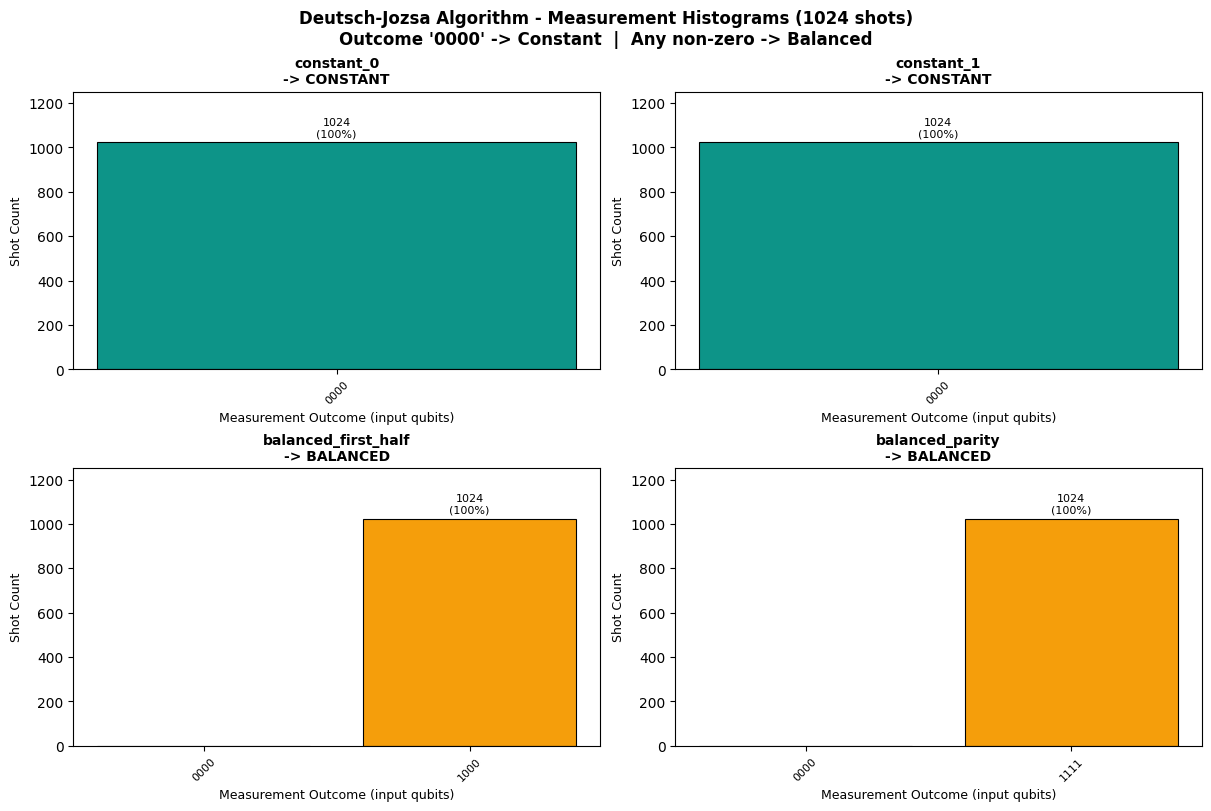

Saved: img/p5_measurement_histograms.png


In [10]:
def plot_dj_histograms(dj_results: dict) -> None:
    """
    Plots measurement histograms for all four Deutsch-Jozsa runs.
    """
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
    fig.suptitle(
        'Deutsch-Jozsa Algorithm - Measurement Histograms (1024 shots)\n'
        "Outcome '0000' -> Constant  |  Any non-zero -> Balanced",
        fontsize=12,
        fontweight='bold',
    )

    for idx, (func_name, result) in enumerate(dj_results.items()):
        ax = axes[idx // 2][idx % 2]
        counts = result['counts']

        all_keys = sorted(set(list(counts.keys()) + ['0000']))
        values = [counts.get(k, 0) for k in all_keys]
        colours = ['#0D9488' if k == '0000' else '#F59E0B' for k in all_keys]

        bars = ax.bar(all_keys, values, color=colours, edgecolor='black', linewidth=0.8)

        for bar, val in zip(bars, values):
            if val > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 15,
                    f'{val}\n({val/1024*100:.0f}%)',
                    ha='center',
                    va='bottom',
                    fontsize=8,
                )

        ftype = result['classification'].upper()
        ax.set_title(f'{func_name}\n-> {ftype}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Measurement Outcome (input qubits)', fontsize=9)
        ax.set_ylabel('Shot Count', fontsize=9)
        ax.set_ylim(0, 1250)
        ax.tick_params(axis='x', labelsize=8, rotation=45)

    plt.savefig('img/p5_measurement_histograms.png', bbox_inches='tight', dpi=150)
    plt.show()
    print('Saved: img/p5_measurement_histograms.png')


plot_dj_histograms(dj_results)

### Classical vs Quantum Query Complexity

The deterministic query gap is summarised below:

| Approach | Algorithm | Queries Required | Complexity |
|---|---|---|---|
| Classical | Deterministic scan | Up to $2^{n-1}+1$ | $O(2^n)$ |
| Classical | Randomised (BPP) | $O(1)$ with bounded error | $O(1)$ |
| Quantum | Deutsch-Jozsa | Exactly 1 | $O(1)$ |

For completeness, the classical randomised setting should be stated explicitly: by sampling a constant number of random inputs, a classical randomised algorithm can distinguish constant from balanced with bounded error in $O(1)$ queries. Therefore, the Deutsch-Jozsa advantage is specifically an exponential separation from deterministic classical query complexity, not from all randomised classical methods. This remains foundational because it was the first clean demonstration that quantum computation can achieve exponential savings for a natural oracle-query task, which initiated modern quantum complexity-theoretic study. The distinction between deterministic and randomised classical complexity in the context of Deutsch-Jozsa is discussed in [Cleve, Ekert, Macchiavello & Mosca (1998)](https://doi.org/10.1098/rspa.1998.0164), which also provides the modern gate-based reformulation of the algorithm used here.

In [11]:
# -- Problem 5 Repository File Audit -----------------------------------
expected_p5_files = [
    'data/p5_truth_tables.csv',
    'data/p5_dj_results.csv',
    'img/p5_dj_circuit_constant_0.png',
    'img/p5_dj_circuit_constant_1.png',
    'img/p5_dj_circuit_balanced_first_half.png',
    'img/p5_dj_circuit_balanced_parity.png',
    'img/p5_measurement_histograms.png',
]

print('Problem 5 - Output File Audit')
print('-' * 48)
all_present = True
for filepath in expected_p5_files:
    exists = os.path.exists(filepath)
    status = 'PASS' if exists else 'MISSING'
    if not exists:
        all_present = False
    print(f'  {status:<8} {filepath}')

print('-' * 48)
if all_present:
    print('All Problem 5 output files present.')
    print('Ready for final commit.')
else:
    print('WARNING: Re-run notebook with Kernel -> Restart & Run All.')

Problem 5 - Output File Audit
------------------------------------------------
  PASS     data/p5_truth_tables.csv
  PASS     data/p5_dj_results.csv
  PASS     img/p5_dj_circuit_constant_0.png
  PASS     img/p5_dj_circuit_constant_1.png
  PASS     img/p5_dj_circuit_balanced_first_half.png
  PASS     img/p5_dj_circuit_balanced_parity.png
  PASS     img/p5_measurement_histograms.png
------------------------------------------------
All Problem 5 output files present.
Ready for final commit.
